In [5]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pytrends.request import TrendReq
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### 📦 Bibliothèques utilisées

- **`os`** : interaction avec le système (fichiers, chemins).
- **`time`** : gestion du temps (délais, timestamps).
- **`numpy` (`np`)** : calcul scientifique et manipulation de tableaux.
- **`pandas` (`pd`)** : analyse et manipulation de données tabulaires.
- **`matplotlib.pyplot` (`plt`)** : visualisation de données (graphiques).
- **`seaborn` (`sns`)** : visualisations statistiques avancées basées sur matplotlib.

### 🔎 Données et tendances
- **`TrendReq` (pytrends)** : récupération des données Google Trends.

### 🤖 Machine Learning
- **`StandardScaler`** : normalisation des données (centrage-réduction).
- **`KMeans`** : algorithme de clustering non supervisé.

In [6]:
# Paramètres généraux
GEO = "FR"
TIMEFRAME = "2020-01-01 2025-12-31"

# Liste de mots-clés
keywords = [
    "intelligence artificielle",
    "ia",
    "chatgpt",
    "openai",
    "machine learning",
    "deep learning",
    "data science",
    "big data",
    "algorithme",
    "robot",
    "automatisation",
    "cybersécurité",
    "cloud computing",
    "serveur",
    "gpu",
    "nvidia",
    "bitcoin",
    "blockchain",
    "réalité virtuelle",
    "metaverse"
]

# Dossiers
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
FIG_DIR = "../figures"

import os
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Paramètres OK")

Paramètres OK


### ⚙️ Paramètres généraux

- **`GEO`** : zone géographique étudiée (`FR` pour la France).
- **`TIMEFRAME`** : période d’analyse des données (de 2020 à 2025).

### 🔑 Mots-clés analysés

Liste de termes liés aux technologies et au numérique :
- Intelligence artificielle, machine learning, deep learning  
- Outils et acteurs (ChatGPT, OpenAI, Nvidia)  
- Concepts data (data science, big data, algorithme)  
- Infrastructures (cloud computing, serveur, GPU)  
- Technologies émergentes (blockchain, metaverse, réalité virtuelle)  
- Sécurité et automatisation (cybersécurité, robot, automatisation)

### 📁 Organisation des données

- **`RAW_DIR`** : stockage des données brutes  
- **`PROCESSED_DIR`** : données nettoyées et transformées  
- **`FIG_DIR`** : visualisations et graphiques  

Les dossiers sont créés automatiquement si inexistants (`os.makedirs` avec `exist_ok=True`).

### ✅ Validation

- Affichage d’un message confirmant que les paramètres sont correctement initialisés.

In [7]:
def recup_tendance(motcle, timeframe=TIMEFRAME, geo=GEO):
    pytrends = TrendReq(hl="fr-FR", tz=360)

    pytrends.build_payload(
        kw_list=[motcle],
        cat=0,
        timeframe=timeframe,
        geo=geo,
        gprop=""
    )

    df = pytrends.interest_over_time()

    if df.empty:
        return pd.DataFrame()

    df = df.reset_index()

    if "isPartial" in df.columns:
        df = df.drop(columns=["isPartial"])

    df = df.rename(columns={motcle: "valeur"})
    df["mot_cle"] = motcle

    return df

### 📈 Fonction `recup_tendance`

Récupère l’évolution temporelle de l’intérêt pour un mot-clé via Google Trends.

### 🔧 Paramètres
- **`motcle`** : terme à analyser  
- **`timeframe`** : période d’étude (par défaut définie globalement)  
- **`geo`** : zone géographique (ex : `FR`)  

### ⚙️ Fonctionnement
1. Initialise une connexion à Google Trends via `TrendReq`.
2. Configure la requête avec :
   - le mot-clé
   - la période
   - la zone géographique
3. Récupère les données d’intérêt dans le temps (`interest_over_time`).

### 🧹 Nettoyage des données
- Retourne un DataFrame vide si aucune donnée.
- Réinitialise l’index (date → colonne).
- Supprime la colonne `isPartial` si présente.
- Renomme la colonne du mot-clé en **`valeur`**.
- Ajoute une colonne **`mot_cle`** pour identifier le terme.

### 📤 Sortie
- Un DataFrame structuré avec :
  - la date
  - la valeur d’intérêt
  - le mot-clé associé

In [10]:
test_df = recup_tendance("chatgpt")
print(test_df.shape)
test_df.head()

(72, 3)


,date,valeur,mot_cle
0,2020-01-01,0,chatgpt
1,2020-02-01,0,chatgpt
2,2020-03-01,0,chatgpt
3,2020-04-01,0,chatgpt
4,2020-05-01,0,chatgpt


### 🧪 Test de la fonction `recup_tendance`

Ce bloc vérifie le bon fonctionnement de la fonction avec le mot-clé **"chatgpt"**.

### ⚙️ Étapes
- Appel de la fonction :
  - `recup_tendance("chatgpt")`
- Stockage du résultat dans **`test_df`**

### 🔍 Vérifications
- **`test_df.shape`** : affiche les dimensions du DataFrame (lignes, colonnes)
- **`test_df.head()`** : affiche les premières lignes pour inspection rapide

### 🎯 Objectif
S’assurer que :
- des données sont bien récupérées
- la structure du DataFrame est correcte
- les colonnes attendues (`date`, `valeur`, `mot_cle`) sont présentes

In [11]:
all_data = []

for mot in keywords:
    try:
        print(f"Récupération : {mot}")
        df_temp = recup_tendance(mot)

        if not df_temp.empty:
            all_data.append(df_temp)
            print(f"  -> {df_temp.shape[0]} lignes récupérées")
        else:
            print(f"  -> aucune donnée")

        time.sleep(2)

    except Exception as e:
        print(f"Erreur pour {mot} : {e}")

Récupération : intelligence artificielle
  -> 72 lignes récupérées
Récupération : ia
  -> 72 lignes récupérées
Récupération : chatgpt
  -> 72 lignes récupérées
Récupération : openai
  -> 72 lignes récupérées
Récupération : machine learning
  -> 72 lignes récupérées
Récupération : deep learning
  -> 72 lignes récupérées
Récupération : data science
  -> 72 lignes récupérées
Récupération : big data
  -> 72 lignes récupérées
Récupération : algorithme
  -> 72 lignes récupérées
Récupération : robot
  -> 72 lignes récupérées
Récupération : automatisation
  -> 72 lignes récupérées
Récupération : cybersécurité
  -> 72 lignes récupérées
Récupération : cloud computing
  -> 72 lignes récupérées
Récupération : serveur
  -> 72 lignes récupérées
Récupération : gpu
  -> 72 lignes récupérées
Récupération : nvidia
  -> 72 lignes récupérées
Récupération : bitcoin
  -> 72 lignes récupérées
Récupération : blockchain
  -> 72 lignes récupérées
Récupération : réalité virtuelle
  -> 72 lignes récupérées
Récupé

### 🔄 Collecte des données pour tous les mots-clés

Ce bloc parcourt la liste des mots-clés et récupère leurs tendances Google Trends.

### ⚙️ Fonctionnement
- Initialise une liste vide **`all_data`** pour stocker les résultats.
- Pour chaque mot-clé dans **`keywords`** :
  1. Affiche le mot en cours de traitement.
  2. Appelle la fonction `recup_tendance(mot)`.
  3. Vérifie si des données ont été récupérées :
     - Si oui : ajoute le DataFrame à `all_data` et affiche le nombre de lignes.
     - Sinon : indique qu’aucune donnée n’est disponible.

### ⏱️ Gestion du rythme
- Pause de **2 secondes** entre chaque requête (`time.sleep(2)`)  
  → évite le blocage par Google Trends.

### ⚠️ Gestion des erreurs
- Utilise un bloc `try/except` :
  - Capture les erreurs pour un mot-clé donné
  - Continue l’exécution sans interrompre la boucle

### 📤 Résultat
- **`all_data`** contient une liste de DataFrames exploitables pour une consolidation ultérieure.

In [12]:
df_long = pd.concat(all_data, ignore_index=True)

print(df_long.shape)
df_long.head()

(1440, 3)


,date,valeur,mot_cle
0,2020-01-01,14,intelligence artificielle
1,2020-02-01,14,intelligence artificielle
2,2020-03-01,12,intelligence artificielle
3,2020-04-01,13,intelligence artificielle
4,2020-05-01,11,intelligence artificielle


### 🧩 Fusion des données

Ce bloc regroupe toutes les données collectées en un seul DataFrame.

### ⚙️ Étapes
- **`pd.concat(all_data, ignore_index=True)`** :
  - Fusionne tous les DataFrames contenus dans `all_data`
  - Réinitialise l’index pour obtenir une numérotation continue

### 🔍 Vérifications
- **`df_long.shape`** : affiche la taille du DataFrame final (lignes, colonnes)
- **`df_long.head()`** : aperçu des premières lignes

### 📊 Résultat
- **`df_long`** contient l’ensemble des données de tendances
- Format “long” :
  - une ligne = une date + un mot-clé + une valeur
```

In [13]:
raw_path = os.path.join(RAW_DIR, "trends_brut_long.csv")

df_long.to_csv(raw_path, index=False, encoding="utf-8-sig")

print("Fichier brut sauvegardé :", raw_path)

Fichier brut sauvegardé : ../data/raw\trends_brut_long.csv


### 💾 Sauvegarde des données brutes

Ce bloc enregistre le DataFrame consolidé dans un fichier CSV.

### ⚙️ Étapes
- **`os.path.join(RAW_DIR, "trends_brut_long.csv")`** :
  - Construit le chemin du fichier de sortie dans le dossier des données brutes

- **`df_long.to_csv(...)`** :
  - Exporte le DataFrame en CSV
  - `index=False` : ne sauvegarde pas l’index
  - `encoding="utf-8-sig"` : assure la compatibilité (notamment avec Excel)

### 📁 Résultat
- Fichier créé : **`trends_brut_long.csv`**
- Contient l’ensemble des données de tendances au format long

### ✅ Confirmation
- Affiche le chemin du fichier sauvegardé pour vérification

In [14]:
print(df_long.shape)
print(df_long.columns)
print(df_long.dtypes)

df_long.head()

(1440, 3)
Index(['date', 'valeur', 'mot_cle'], dtype='str')
date       datetime64[s]
valeur             int64
mot_cle              str
dtype: object


,date,valeur,mot_cle
0,2020-01-01,14,intelligence artificielle
1,2020-02-01,14,intelligence artificielle
2,2020-03-01,12,intelligence artificielle
3,2020-04-01,13,intelligence artificielle
4,2020-05-01,11,intelligence artificielle


In [15]:
df_long.info()
print(df_long.isnull().sum())
print("Doublons :", df_long.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype        
---  ------   --------------  -----        
 0   date     1440 non-null   datetime64[s]
 1   valeur   1440 non-null   int64        
 2   mot_cle  1440 non-null   str          
dtypes: datetime64[s](1), int64(1), str(1)
memory usage: 33.9 KB
date       0
valeur     0
mot_cle    0
dtype: int64
Doublons : 0


### 🔍 Analyse exploratoire et qualité des données

Cette étape combine une inspection rapide de la structure et un diagnostic de qualité du DataFrame **`df_long`**.

### 📊 Structure des données
- **`df_long.shape`** : dimensions (lignes, colonnes)
- **`df_long.columns`** : noms des variables
- **`df_long.dtypes`** : types de données
- **`df_long.head()`** : aperçu des premières observations

### 🧹 Qualité des données
- **`df_long.info()`** :
  - résumé global (types, valeurs non nulles, mémoire)
- **`df_long.isnull().sum()`** :
  - détection des valeurs manquantes par colonne
- **`df_long.duplicated().sum()`** :
  - identification des doublons

### 🎯 Objectif
Vérifier que :
- la structure est cohérente
- les types sont corrects
- les données sont complètes et sans duplication

afin de préparer les étapes de nettoyage et d’analyse.

In [16]:
df_long["date"] = pd.to_datetime(df_long["date"])
df_long["mot_cle"] = df_long["mot_cle"].str.strip().str.lower()

df_long = df_long.dropna(subset=["date", "valeur", "mot_cle"])
df_long = df_long.drop_duplicates()
df_long = df_long.sort_values(["mot_cle", "date"]).reset_index(drop=True)

df_long.head()

,date,valeur,mot_cle
0,2020-01-01,85,algorithme
1,2020-02-01,83,algorithme
2,2020-03-01,90,algorithme
3,2020-04-01,70,algorithme
4,2020-05-01,74,algorithme


### 🧹 Nettoyage et préparation des données

Cette étape standardise et fiabilise le DataFrame **`df_long`** avant analyse.

### ⚙️ Transformations
- **Conversion des dates** :
  - `date` → format datetime pour faciliter les analyses temporelles

- **Normalisation des mots-clés** :
  - suppression des espaces inutiles (`strip`)
  - mise en minuscules (`lower`)
  → évite les doublons liés à la casse ou aux espaces

### 🧼 Nettoyage
- Suppression des lignes avec valeurs manquantes sur :
  - `date`, `valeur`, `mot_cle`
- Suppression des doublons

### 🔄 Organisation
- Tri des données par **mot-clé** puis **date**
- Réinitialisation de l’index

### 🔍 Vérification
- **`df_long.head()`** : aperçu après nettoyage

### 🎯 Objectif
Obtenir un dataset propre, homogène et prêt pour l’analyse ou la modélisation.

In [17]:
clean_long_path = os.path.join(PROCESSED_DIR, "trends_clean_long.csv")
df_long.to_csv(clean_long_path, index=False, encoding="utf-8-sig")

print("Fichier propre sauvegardé :", clean_long_path)

Fichier propre sauvegardé : ../data/processed\trends_clean_long.csv


In [18]:
df_wide = df_long.pivot(index="date", columns="mot_cle", values="valeur")
df_wide = df_wide.sort_index()

print(df_wide.shape)
df_wide.head()

(72, 20)


mot_cle,algorithme,automatisation,big data,bitcoin,blockchain,chatgpt,cloud computing,cybersécurité,data science,deep learning,gpu,ia,intelligence artificielle,machine learning,metaverse,nvidia,openai,robot,réalité virtuelle,serveur
date,,,,,,,,,,,,,,,,,,,,
2020-01-01,85,45,89,18,56,0,32,8,28,37,18,4,14,34,0,21,0,62,92,64
2020-02-01,83,40,95,22,45,0,30,7,27,39,18,4,14,36,0,22,0,52,100,72
2020-03-01,90,37,80,40,35,0,29,6,23,33,19,6,12,31,0,24,0,53,63,88
2020-04-01,70,35,75,29,39,0,29,5,26,34,23,5,13,35,0,28,0,92,58,100
2020-05-01,74,34,85,32,37,0,27,5,23,33,23,5,11,33,0,27,0,95,59,86


### 🔄 Transformation en format large (wide)

Cette étape restructure les données pour faciliter l’analyse comparative entre mots-clés.

### ⚙️ Transformation
- **`pivot(index="date", columns="mot_cle", values="valeur")`** :
  - chaque **ligne** représente une date
  - chaque **colonne** correspond à un mot-clé
  - les **valeurs** indiquent l’intérêt (Google Trends)

- **Tri des dates** :
  - `sort_index()` assure un ordre chronologique

### 🔍 Vérifications
- **`df_wide.shape`** : dimensions du nouveau DataFrame
- **`df_wide.head()`** : aperçu des premières lignes

### 📊 Résultat
- Format “large” :
  - une ligne = une date
  - une colonne = un mot-clé
- Idéal pour :
  - visualisations multi-séries
  - corrélations
  - modèles de machine learning

### 🎯 Objectif
Passer d’un format long à un format exploitable pour analyses comparatives et algorithmes.

In [19]:
df_wide = df_wide.interpolate(method="linear", axis=0)
df_wide = df_wide.bfill().ffill()

print(df_wide.isnull().sum())
df_wide.head()

mot_cle
algorithme                   0
automatisation               0
big data                     0
bitcoin                      0
blockchain                   0
chatgpt                      0
cloud computing              0
cybersécurité                0
data science                 0
deep learning                0
gpu                          0
ia                           0
intelligence artificielle    0
machine learning             0
metaverse                    0
nvidia                       0
openai                       0
robot                        0
réalité virtuelle            0
serveur                      0
dtype: int64


mot_cle,algorithme,automatisation,big data,bitcoin,blockchain,chatgpt,cloud computing,cybersécurité,data science,deep learning,gpu,ia,intelligence artificielle,machine learning,metaverse,nvidia,openai,robot,réalité virtuelle,serveur
date,,,,,,,,,,,,,,,,,,,,
2020-01-01,85,45,89,18,56,0,32,8,28,37,18,4,14,34,0,21,0,62,92,64
2020-02-01,83,40,95,22,45,0,30,7,27,39,18,4,14,36,0,22,0,52,100,72
2020-03-01,90,37,80,40,35,0,29,6,23,33,19,6,12,31,0,24,0,53,63,88
2020-04-01,70,35,75,29,39,0,29,5,26,34,23,5,13,35,0,28,0,92,58,100
2020-05-01,74,34,85,32,37,0,27,5,23,33,23,5,11,33,0,27,0,95,59,86


### 🧩 Gestion des valeurs manquantes

Cette étape traite les éventuels trous dans les séries temporelles.

### ⚙️ Méthodes appliquées
- **Interpolation linéaire** :
  - `interpolate(method="linear", axis=0)`
  - estime les valeurs manquantes en fonction des points voisins

- **Remplissage complémentaire** :
  - `bfill()` : remplit vers l’arrière (valeurs suivantes)
  - `ffill()` : remplit vers l’avant (valeurs précédentes)

### 🔍 Vérifications
- **`df_wide.isnull().sum()`** :
  - nombre de valeurs manquantes restantes par colonne
- **`df_wide.head()`** :
  - aperçu après traitement

### 📊 Résultat
- Séries temporelles complètes et continues
- Plus de valeurs nulles (dans la majorité des cas)

### 🎯 Objectif
Préparer des données exploitables pour :
- visualisation
- calculs statistiques
- modèles de machine learning
```

In [20]:
wide_path = os.path.join(PROCESSED_DIR, "trends_clean_wide.csv")
df_wide.to_csv(wide_path, encoding="utf-8-sig")

print("Fichier wide sauvegardé :", wide_path)

Fichier wide sauvegardé : ../data/processed\trends_clean_wide.csv


### 🧩 Traitement des valeurs manquantes

Cette étape complète les séries temporelles en comblant les valeurs absentes.

### ⚙️ Méthodes utilisées
- **Interpolation linéaire** :
  - estime les valeurs manquantes entre deux points connus

- **Remplissage des bords** :
  - `bfill()` : remplit avec la valeur suivante
  - `ffill()` : remplit avec la valeur précédente

### 🔍 Contrôle
- **`df_wide.isnull().sum()`** :
  - vérifie qu’il ne reste plus de valeurs manquantes
- **`df_wide.head()`** :
  - aperçu du DataFrame final

### 🎯 Objectif
Obtenir des séries complètes, sans discontinuité, prêtes pour l’analyse et la modélisation.

In [21]:
stats_df = df_long.groupby("mot_cle")["valeur"].agg(
    moyenne="mean",
    mediane="median",
    minimum="min",
    maximum="max",
    ecart_type="std"
).reset_index()

stats_df["amplitude"] = stats_df["maximum"] - stats_df["minimum"]
stats_df = stats_df.sort_values("moyenne", ascending=False).reset_index(drop=True)

stats_df.head(10)

,mot_cle,moyenne,mediane,minimum,maximum,ecart_type,amplitude
0,serveur,72.763889,71.5,64,100,7.293626,36
1,robot,67.277778,63.5,49,100,12.681607,51
2,algorithme,66.902778,71.0,27,100,17.641309,73
3,réalité virtuelle,62.944444,61.0,39,100,14.033048,61
4,big data,59.208333,57.5,28,100,18.607084,72
5,automatisation,59.027778,58.0,32,100,16.658942,68
6,blockchain,56.472222,52.0,31,100,17.327802,69
7,bitcoin,41.958333,39.0,17,100,18.251326,83
8,machine learning,37.597222,35.5,19,100,12.027738,81
9,deep learning,37.319444,34.5,21,100,11.521965,79


### 📊 Statistiques descriptives par mot-clé

Cette étape calcule des indicateurs clés pour chaque mot-clé afin de comparer leur popularité.

### ⚙️ Calculs effectués
- Regroupement par **`mot_cle`**
- Agrégation des métriques sur **`valeur`** :
  - **moyenne** : niveau d’intérêt moyen  
  - **médiane** : valeur centrale  
  - **minimum / maximum** : bornes observées  
  - **écart-type** : variabilité (dispersion)

### ➕ Indicateur נוסף
- **`amplitude`** :
  - différence entre maximum et minimum
  - mesure l’ampleur des variations

### 🔄 Organisation
- Tri décroissant par **moyenne**
- Réinitialisation de l’index

### 🔍 Résultat
- **`stats_df.head(10)`** :
  - top 10 des mots-clés les plus populaires en moyenne

### 🎯 Objectif
Comparer :
- le niveau global d’intérêt
- la stabilité ou volatilité des tendances
- les mots-clés dominants

In [22]:
evolution_rows = []

for col in df_wide.columns:
    serie = df_wide[col].dropna()

    debut = serie.iloc[:8].mean()
    fin = serie.iloc[-8:].mean()
    variation_absolue = fin - debut

    if debut != 0:
        variation_relative = (fin - debut) / debut
    else:
        variation_relative = np.nan

    evolution_rows.append({
        "mot_cle": col,
        "moyenne_debut": debut,
        "moyenne_fin": fin,
        "variation_absolue": variation_absolue,
        "variation_relative": variation_relative
    })

evolution_df = pd.DataFrame(evolution_rows)
evolution_df.head()

,mot_cle,moyenne_debut,moyenne_fin,variation_absolue,variation_relative
0,algorithme,68.750,47.750,-21.000,-0.305455
1,automatisation,37.375,83.000,45.625,1.220736
2,big data,76.250,52.875,-23.375,-0.306557
3,bitcoin,24.875,43.125,18.250,0.733668
4,blockchain,41.750,64.250,22.500,0.538922


### 📈 Analyse de l’évolution des tendances

Cette étape mesure l’évolution de chaque mot-clé entre le début et la fin de la période.

### ⚙️ Méthode
- Parcourt chaque colonne (mot-clé) du DataFrame **`df_wide`**
- Pour chaque série temporelle :
  - **Début** : moyenne des 8 premières valeurs
  - **Fin** : moyenne des 8 dernières valeurs

### 📊 Indicateurs calculés
- **`moyenne_debut`** : niveau initial moyen  
- **`moyenne_fin`** : niveau final moyen  
- **`variation_absolue`** :
  - différence entre fin et début  
- **`variation_relative`** :
  - évolution en pourcentage  
  - calculée uniquement si la valeur initiale ≠ 0

### 🧩 Construction du résultat
- Stockage des résultats dans une liste de dictionnaires
- Conversion en DataFrame **`evolution_df`**

### 🔍 Vérification
- **`evolution_df.head()`** : aperçu des premières lignes

### 🎯 Objectif
Identifier :
- les mots-clés en forte croissance
- ceux en déclin
- les dynamiques globales sur la période

In [23]:
stats_df = stats_df.merge(evolution_df, on="mot_cle", how="left")

stats_df["rang_popularite"] = stats_df["moyenne"].rank(ascending=False, method="dense")
stats_df["rang_volatilite"] = stats_df["ecart_type"].rank(ascending=False, method="dense")

stats_df.head(10)

,mot_cle,moyenne,mediane,minimum,maximum,ecart_type,amplitude,moyenne_debut,moyenne_fin,variation_absolue,variation_relative,rang_popularite,rang_volatilite
0,serveur,72.763889,71.5,64,100,7.293626,36,77.375,67.000,-10.375,-0.134087,1.0,20.0
1,robot,67.277778,63.5,49,100,12.681607,51,66.875,74.750,7.875,0.117757,2.0,15.0
2,algorithme,66.902778,71.0,27,100,17.641309,73,68.750,47.750,-21.000,-0.305455,3.0,7.0
3,réalité virtuelle,62.944444,61.0,39,100,14.033048,61,67.125,52.125,-15.000,-0.223464,4.0,13.0
4,big data,59.208333,57.5,28,100,18.607084,72,76.250,52.875,-23.375,-0.306557,5.0,5.0
5,automatisation,59.027778,58.0,32,100,16.658942,68,37.375,83.000,45.625,1.220736,6.0,11.0
6,blockchain,56.472222,52.0,31,100,17.327802,69,41.750,64.250,22.500,0.538922,7.0,9.0
7,bitcoin,41.958333,39.0,17,100,18.251326,83,24.875,43.125,18.250,0.733668,8.0,6.0
8,machine learning,37.597222,35.5,19,100,12.027738,81,32.125,50.750,18.625,0.579767,9.0,17.0
9,deep learning,37.319444,34.5,21,100,11.521965,79,34.500,48.625,14.125,0.409420,10.0,19.0


### 🔗 Enrichissement et classement des mots-clés

Cette étape combine les statistiques descriptives avec les indicateurs d’évolution, puis ajoute des classements.

### ⚙️ Fusion des données
- **`merge(evolution_df, on="mot_cle", how="left")`** :
  - associe les métriques d’évolution à chaque mot-clé
  - conserve tous les mots-clés présents dans `stats_df`

### 🏆 Classements
- **`rang_popularite`** :
  - basé sur la **moyenne** (ordre décroissant)
  - identifie les mots-clés les plus populaires

- **`rang_volatilite`** :
  - basé sur l’**écart-type** (ordre décroissant)
  - met en évidence les tendances les plus instables

- Méthode **`dense`** :
  - pas de saut dans les rangs (ex : 1, 2, 2, 3)

### 🔍 Vérification
- **`stats_df.head(10)`** :
  - aperçu des mots-clés les mieux classés

### 🎯 Objectif
Disposer d’une vue synthétique combinant :
- popularité
- évolution
- volatilité

pour faciliter l’analyse et la priorisation des tendances.

In [24]:
stats_path = os.path.join(PROCESSED_DIR, "stats_par_motcle.csv")
stats_df.to_csv(stats_path, index=False, encoding="utf-8-sig")

print("Fichier stats sauvegardé :", stats_path)

Fichier stats sauvegardé : ../data/processed\stats_par_motcle.csv


In [25]:
corr_matrix = df_wide.corr()
corr_matrix.head()

mot_cle,algorithme,automatisation,big data,bitcoin,blockchain,chatgpt,cloud computing,cybersécurité,data science,deep learning,gpu,ia,intelligence artificielle,machine learning,metaverse,nvidia,openai,robot,réalité virtuelle,serveur
mot_cle,,,,,,,,,,,,,,,,,,,,
algorithme,1.000000,-0.104899,0.647579,0.171944,0.378246,-0.347640,0.042504,-0.031241,0.049401,0.181354,-0.180405,-0.333866,-0.010327,0.146177,0.391729,-0.197258,-0.175898,0.210836,0.499783,0.462629
automatisation,-0.104899,1.000000,-0.230252,0.124475,0.055089,0.842549,0.619849,0.629594,0.491192,0.530919,0.773796,0.901466,0.754969,0.593116,-0.090386,0.786428,0.716187,0.166367,0.021154,-0.152493
big data,0.647579,-0.230252,1.000000,-0.005241,0.298662,-0.284685,0.300253,-0.282512,0.393614,0.397867,0.003290,-0.380391,-0.368888,0.364197,0.232998,-0.120925,-0.133096,0.143958,0.361443,0.350734
bitcoin,0.171944,0.124475,-0.005241,1.000000,0.580135,0.070216,0.236816,0.072916,0.186821,0.176279,0.227548,0.081137,-0.000444,0.183869,0.117419,0.230595,0.002603,0.289705,-0.048952,0.236821
blockchain,0.378246,0.055089,0.298662,0.580135,1.000000,-0.034963,0.241033,-0.081016,0.253165,0.298348,0.131151,-0.129881,-0.176956,0.294017,0.647337,0.000418,-0.065661,0.217446,0.184998,0.285967


In [26]:
corr_path = os.path.join(PROCESSED_DIR, "matrice_correlation.csv")
corr_matrix.to_csv(corr_path, encoding="utf-8-sig")

print("Matrice de corrélation sauvegardée :", corr_path)

Matrice de corrélation sauvegardée : ../data/processed\matrice_correlation.csv


### 🔗 Analyse des corrélations

Cette étape mesure les relations entre les différents mots-clés.

### ⚙️ Calcul
- **`df_wide.corr()`** :
  - calcule la matrice de corrélation (Pearson) entre toutes les colonnes
  - chaque valeur ∈ [-1, 1]

### 📊 Interprétation
- **+1** : évolution très similaire (corrélation positive forte)  
- **0** : aucune relation linéaire  
- **-1** : évolution opposée (corrélation négative forte)  

### 🔍 Vérification
- **`corr_matrix.head()`** :
  - aperçu de la matrice

### 🎯 Objectif
Identifier :
- les mots-clés qui évoluent ensemble
- les groupes de tendances similaires
- les éventuelles oppositions dans les dynamiques

In [27]:
X = df_wide.T

print(X.shape)
X.head()

(20, 72)


date,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
mot_cle,,,,,,,,,,,,,,,,,,,,,
algorithme,85,83,90,70,74,71,39,38,81,82,...,71,60,57,52,32,27,56,49,60,49
automatisation,45,40,37,35,34,38,36,34,56,51,...,92,86,78,86,74,73,84,80,89,100
big data,89,95,80,75,85,75,62,49,100,79,...,41,35,37,40,32,28,55,46,86,99
bitcoin,18,22,40,29,32,17,18,23,17,18,...,49,44,40,31,37,38,29,46,70,54
blockchain,56,45,35,39,37,35,44,43,41,39,...,45,48,66,84,69,51,50,44,73,77


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print(X_scaled_df.shape)
X_scaled_df.head()

(20, 72)


date,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
mot_cle,,,,,,,,,,,,,,,,,,,,,
algorithme,1.682493,1.568188,2.037196,1.202087,1.345481,1.611019,0.563800,0.584285,1.679182,1.837043,...,0.743387,0.348322,0.525970,0.216270,-0.447621,-0.628658,0.544612,0.075164,-0.620794,-0.913725
automatisation,0.327010,0.154518,0.127888,0.006830,-0.015309,0.288541,0.422260,0.387058,0.776396,0.678379,...,1.689515,1.494698,1.486438,1.764305,1.751219,1.875089,1.888148,1.578447,0.438207,0.895983
big data,1.818041,1.962701,1.676949,1.372837,1.719699,1.771319,1.648938,1.126659,2.365299,1.724914,...,-0.608225,-0.753963,-0.388761,-0.330096,-0.447621,-0.574229,0.496629,-0.070315,0.328655,0.860499
bitcoin,-0.587941,-0.437252,0.235962,-0.198071,-0.083348,-0.553036,-0.426978,-0.155316,-0.631950,-0.555037,...,-0.247796,-0.357140,-0.251551,-0.739870,-0.185854,-0.029936,-0.750941,-0.070315,-0.255621,-0.736303
blockchain,0.699768,0.318898,0.055838,0.143431,0.086750,0.168315,0.799700,0.830818,0.234724,0.229864,...,-0.428010,-0.180775,0.937599,1.673244,1.489452,0.677644,0.256711,-0.167301,-0.146069,0.079840


In [30]:
scaled_path = os.path.join(PROCESSED_DIR, "X_scaled_clustering.csv")
X_scaled_df.to_csv(scaled_path, encoding="utf-8-sig")

print("Données normalisées sauvegardées :", scaled_path)

Données normalisées sauvegardées : ../data/processed\X_scaled_clustering.csv


In [31]:
inertias = []
k_values = range(2, 7)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled_df)
    inertias.append(model.inertia_)

In [32]:
elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertie": inertias
})

elbow_df

,k,inertie
0,2,617.587173
1,3,488.075789
2,4,373.860016
3,5,316.189006
4,6,261.035740


In [33]:
elbow_path = os.path.join(PROCESSED_DIR, "elbow_data.csv")
elbow_df.to_csv(elbow_path, index=False, encoding="utf-8-sig")

print("Données du coude sauvegardées :", elbow_path)

Données du coude sauvegardées : ../data/processed\elbow_data.csv


In [34]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_df)

cluster_df = pd.DataFrame({
    "mot_cle": X_scaled_df.index,
    "cluster": clusters
}).sort_values("cluster").reset_index(drop=True)

cluster_df

,mot_cle,cluster
0,algorithme,0
1,automatisation,0
2,big data,0
3,blockchain,0
4,réalité virtuelle,0
5,serveur,0
6,robot,0
7,bitcoin,1
8,nvidia,1
9,metaverse,1


In [35]:
cluster_path = os.path.join(PROCESSED_DIR, "clusters_motscles.csv")
cluster_df.to_csv(cluster_path, index=False, encoding="utf-8-sig")

print("Clusters sauvegardés :", cluster_path)

Clusters sauvegardés : ../data/processed\clusters_motscles.csv


### 🤖 Préparation des données et clustering des mots-clés

Cette séquence de cellules prépare les séries temporelles pour le clustering, applique une normalisation, détermine un nombre pertinent de groupes avec la méthode du coude, puis réalise le clustering final des mots-clés.

### 1. Préparation de la matrice d’entrée
- **`X = df_wide.T`** :
  - transpose le DataFrame pour adapter la structure au clustering
  - **chaque ligne représente un mot-clé**
  - **chaque colonne représente une date**
- **`X.shape`** et **`X.head()`** :
  - permettent de vérifier la dimension et l’aperçu de la matrice

### 2. Normalisation des données
- **`StandardScaler()`** :
  - standardise chaque variable
  - centre les données autour de 0
  - réduit l’échelle pour obtenir une variance comparable
- **`X_scaled = scaler.fit_transform(X)`** :
  - applique la normalisation à l’ensemble des mots-clés

### 3. Reconstruction en DataFrame
- **`X_scaled_df = pd.DataFrame(...)`** :
  - reconstruit les données normalisées sous forme de DataFrame
  - conserve les **mots-clés en index** et les **dates en colonnes**
- **`X_scaled_df.shape`** et **`X_scaled_df.head()`** :
  - vérifient la structure finale des données normalisées

### 4. Sauvegarde des données normalisées
- Export du fichier **`X_scaled_clustering.csv`** dans le dossier des données traitées
- Cette sauvegarde permet de réutiliser directement la matrice standardisée pour d’autres analyses ou modèles

### 5. Méthode du coude
- Initialisation de :
  - **`inertias = []`**
  - **`k_values = range(2, 7)`**
- Pour chaque valeur de **k** :
  - création d’un modèle **KMeans**
  - apprentissage sur **`X_scaled_df`**
  - récupération de l’**inertie**
- L’inertie mesure la compacité des groupes :
  - plus elle est faible, plus les points sont proches du centre de leur cluster

### 6. Tableau récapitulatif du coude
- Création de **`elbow_df`** avec :
  - **`k`** : nombre de clusters testés
  - **`inertie`** : score associé
- Ce tableau facilite l’identification du “coude”, c’est-à-dire du nombre de clusters offrant un bon compromis entre simplicité et qualité de segmentation

### 7. Sauvegarde des résultats du coude
- Export du fichier **`elbow_data.csv`**
- Permet de conserver les résultats intermédiaires pour visualisation ou justification méthodologique

### 8. Clustering final
- Création d’un modèle **KMeans** avec **`n_clusters=3`**
- **`fit_predict(X_scaled_df)`** :
  - entraîne le modèle
  - attribue un cluster à chaque mot-clé
- Construction de **`cluster_df`** :
  - une colonne **`mot_cle`**
  - une colonne **`cluster`**
- Tri par numéro de cluster puis réinitialisation de l’index

### 9. Sauvegarde des clusters
- Export du fichier **`clusters_motscles.csv`**
- Ce fichier contient l’affectation finale de chaque mot-clé à un groupe

### 🎯 Objectif
Cette étape permet de :
- transformer les séries temporelles en matrice exploitable
- rendre les variables comparables grâce à la normalisation
- choisir un nombre cohérent de clusters
- regrouper les mots-clés selon la similarité de leurs évolutions dans le temps

### 📁 Fichiers produits
- **`X_scaled_clustering.csv`** : données normalisées
- **`elbow_data.csv`** : résultats de la méthode du coude
- **`clusters_motscles.csv`** : affectation finale des mots-clés aux clusters

C:\Users\canpe\AppData\Local\Temp\ipykernel_1172\2673337239.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


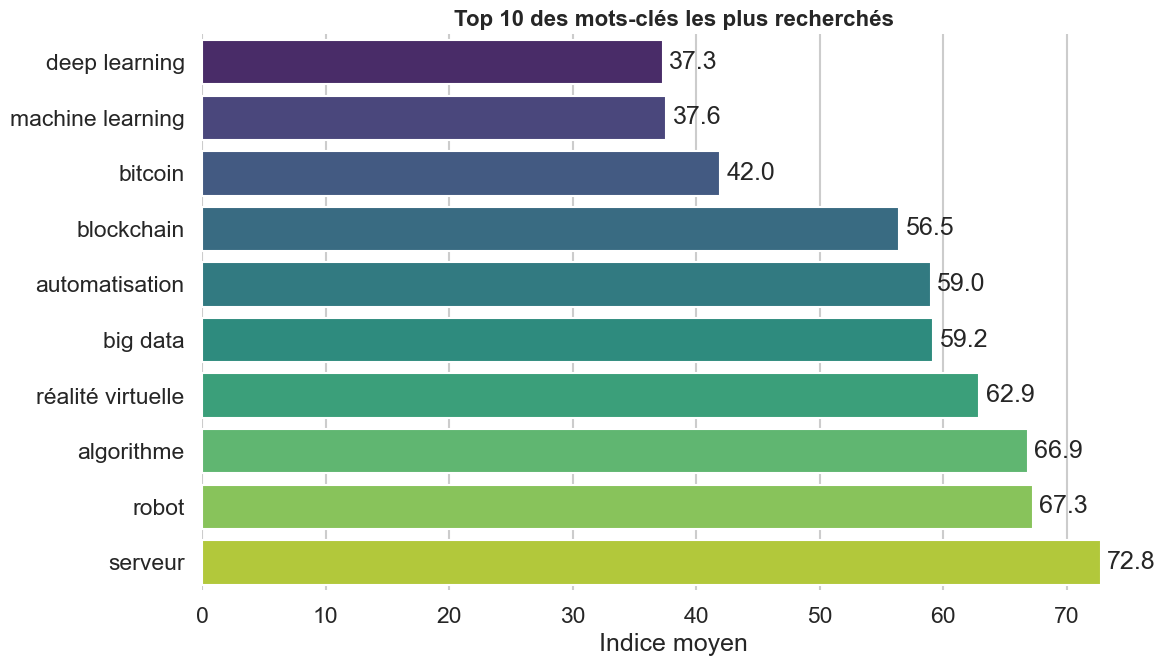

In [37]:
top10 = stats_df.sort_values("moyenne", ascending=True).tail(10)

plt.figure(figsize=(12, 7))

# Style global
sns.set_style("whitegrid")
sns.set_context("talk")

# Palette dégradée
palette = sns.color_palette("viridis", len(top10))

ax = sns.barplot(
    data=top10,
    x="moyenne",
    y="mot_cle",
    palette=palette
)

# Ajout des valeurs sur les barres
for i, v in enumerate(top10["moyenne"]):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center")

# Titres et labels
plt.title("Top 10 des mots-clés les plus recherchés", fontsize=16, weight="bold")
plt.xlabel("Indice moyen")
plt.ylabel("")

# Finition esthétique
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Sauvegarde
plt.savefig(os.path.join(FIG_DIR, "top10_motscles.png"), dpi=300)
plt.show()

### 📊 Explication simple du graphique

Ce graphique montre **les 10 mots-clés les plus recherchés en moyenne** sur la période.

### 🔎 Comment lire concrètement
- À gauche → les **mots-clés**
- En bas → le **niveau d’intérêt moyen** (score Google Trends)
- Plus la barre est longue → plus le mot-clé est populaire

### 📈 Ce que le graphique dit vraiment

- **"serveur" (72.8)** est le mot-clé **le plus recherché** → c’est le sujet dominant  
- Ensuite :
  - **robot (67.3)**  
  - **algorithme (66.9)**  
  → très populaires aussi  

- Puis un groupe intermédiaire :
  - **réalité virtuelle, big data, automatisation (~59–63)**  
  → sujets importants mais moins dominants  

- Ensuite :
  - **blockchain (56.5)** → encore notable mais en retrait  

- Enfin les moins recherchés du top 10 :
  - **bitcoin (42)**  
  - **machine learning / deep learning (~37)**  
  → présents mais clairement moins populaires

### 🎯 En résumé très clair
- Les gens s’intéressent **surtout à l’infrastructure et aux concepts techniques** (serveur, robot, algorithme)  
- Les sujets **IA avancée (deep learning, ML)** sont **moins recherchés que prévu**  
- Il y a une **hiérarchie nette** : certains sujets dominent largement

👉 Ce n’est pas que les derniers ne sont pas importants,  
mais ils sont **moins recherchés par le grand public**.

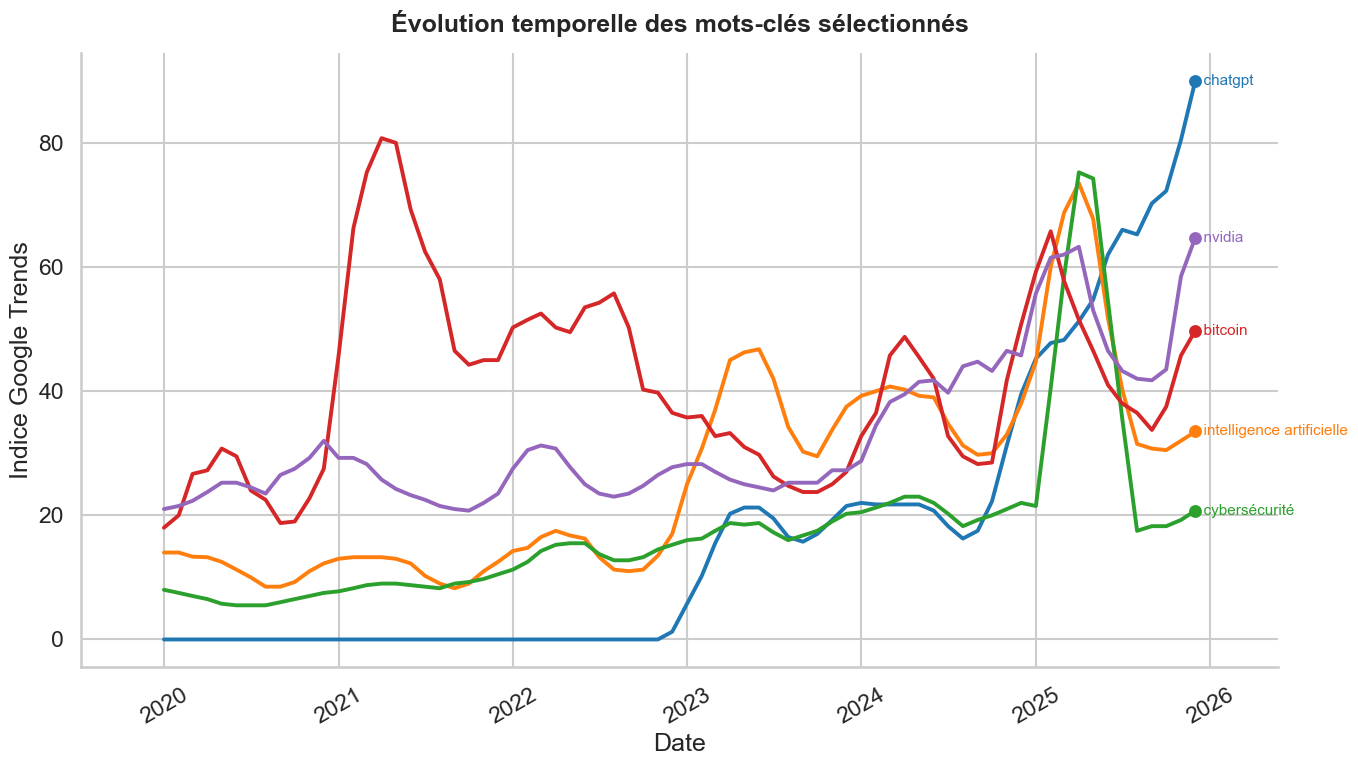

In [43]:
selection = ["chatgpt", "intelligence artificielle", "cybersécurité", "bitcoin", "nvidia"]

# On garde uniquement les mots-clés présents
selection_valides = [mot for mot in selection if mot in df_wide.columns]

# Style global
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(14, 8))

palette = sns.color_palette("tab10", len(selection_valides))

for i, mot in enumerate(selection_valides):
    serie = df_wide[mot].copy()

    # Lissage léger pour rendre les courbes plus lisibles
    serie_lissee = serie.rolling(window=4, min_periods=1).mean()

    ax.plot(
        df_wide.index,
        serie_lissee,
        label=mot,
        linewidth=2.8,
        color=palette[i]
    )

    # Mettre en valeur le dernier point
    ax.scatter(
        df_wide.index[-1],
        serie_lissee.iloc[-1],
        s=60,
        color=palette[i],
        zorder=3
    )

    # Ajouter le nom du mot-clé à droite
    ax.text(
        df_wide.index[-1],
        serie_lissee.iloc[-1],
        f"  {mot}",
        va="center",
        fontsize=11,
        color=palette[i]
    )

# Titres et labels
ax.set_title("Évolution temporelle des mots-clés sélectionnés", fontsize=18, weight="bold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Indice Google Trends")

# Un peu d'espace à droite pour les labels
ax.margins(x=0.08)

# Rotation des dates
plt.xticks(rotation=30)

# Supprimer la légende car les labels sont déjà sur les courbes
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Nettoyage visuel
sns.despine()
plt.tight_layout()

# Sauvegarde
plt.savefig(
    os.path.join(FIG_DIR, "courbes_selection.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📈 Évolution temporelle de mots-clés sélectionnés

Ce graphique compare l’évolution de plusieurs mots-clés sur la période étudiée.

Chaque courbe représente un mot-clé, et sa position dans le temps montre comment son niveau d’intérêt évolue.  
Un léger lissage est appliqué pour rendre les tendances plus lisibles et réduire les variations trop brutales.

Les points en fin de courbe mettent en évidence le niveau atteint à la dernière date observée, ce qui facilite la comparaison finale entre les différents sujets.

### 🎯 Objectif
Ce graphique permet de :
- suivre l’évolution de chaque mot-clé dans le temps
- repérer les tendances haussières, baissières ou stables
- comparer visuellement la dynamique des différents sujets

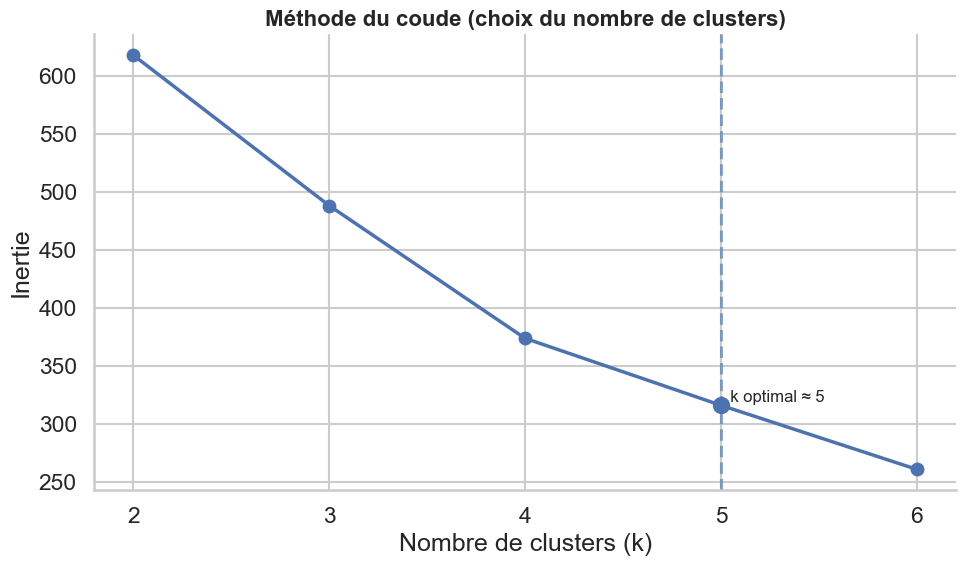

In [45]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(10, 6))

# Courbe principale
ax.plot(
    elbow_df["k"],
    elbow_df["inertie"],
    marker="o",
    linewidth=2.5
)

# Détection simple du coude (variation de pente)
diffs = np.diff(elbow_df["inertie"])
diffs2 = np.diff(diffs)
k_opt = elbow_df["k"].iloc[np.argmin(diffs2) + 1]

# Highlight du point optimal
y_opt = elbow_df.loc[elbow_df["k"] == k_opt, "inertie"].values[0]

ax.scatter(k_opt, y_opt, s=120, zorder=3)
ax.axvline(k_opt, linestyle="--", alpha=0.6)

# Annotation
ax.text(
    k_opt,
    y_opt,
    f"  k optimal ≈ {k_opt}",
    va="bottom",
    fontsize=12
)

# Mise en forme
ax.set_title("Méthode du coude (choix du nombre de clusters)", fontsize=16, weight="bold")
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Inertie")

ax.set_xticks(elbow_df["k"])

sns.despine()
plt.tight_layout()

# Sauvegarde HD
plt.savefig(os.path.join(FIG_DIR, "elbow_method.png"), dpi=300, bbox_inches="tight")
plt.show()

### 📉 Méthode du coude

Ce graphique montre comment l’inertie diminue lorsque le nombre de clusters augmente.

- Chaque point correspond à un nombre de clusters (k)
- L’inertie mesure la compacité des groupes (plus c’est bas, mieux c’est)

Le point mis en évidence correspond au **“coude”** :
- c’est le moment où ajouter des clusters n’améliore plus beaucoup le modèle

### 🎯 Conclusion
Le nombre de clusters optimal se situe autour de ce point.